# Fisher analysis with PyCBC: a worked example

This notebook walks through a simple Fisher matrix forecast for a binary black hole seen by a
single ground-based detector. It measures four parameters:

$$\theta = (\ln\mathcal{M}_c,\; q,\; t_c,\; \phi_c).$$

## 1. Theory in brief

With Gaussian, stationary noise and a strong signal, the likelihood near the true parameters
$\theta_0$ is approximately Gaussian:

$$\ln \mathcal{L}(\theta) \approx -\tfrac12\, \Gamma_{ij}\,\Delta\theta^i\Delta\theta^j,\qquad
\Gamma_{ij} = \left(\frac{\partial h}{\partial\theta^i}\,\middle|\,\frac{\partial h}{\partial\theta^j}\right).$$

The noise-weighted inner product is eq. (2.3) of Cutler & Flanagan (1994):

$$(a\,|\,b) = 2\int_{f_{\min}}^{f_{\max}} \frac{\tilde a^*(f)\,\tilde b(f) + \tilde a(f)\,\tilde b^*(f)}{S_n(f)}\,df
= 4\,\mathrm{Re}\int \frac{\tilde a^*\tilde b}{S_n}\,df .$$

The covariance is $\Sigma = \Gamma^{-1}$, so the $1\sigma$ error on $\theta^i$ is $\sqrt{\Sigma_{ii}}$.
The signal-to-noise ratio is $\rho = \sqrt{(h|h)}$.

The hard part in practice is the derivative $\partial_i \tilde h(f)$. For PyCBC waveforms we take it
**numerically, with finite differences**, as explained in Section 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.integrate import simpson

import pycbc.waveform
import pycbc.conversions as pycbcConv

/opt/homebrew/Caskroom/miniconda/base/envs/tobias-lensing/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


/opt/homebrew/Caskroom/miniconda/base/envs/tobias-lensing/lib/python3.11/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Noise curve

The noise curves in `curves/` are amplitude spectral densities $\sqrt{S_n(f)}$ in $1/\sqrt{\rm Hz}$.
`read_mag` interpolates them in log-log space onto our frequency grid. Outside the tabulated band it
returns `inf`, so $1/S_n \to 0$ there and those frequencies contribute nothing to the integrals.

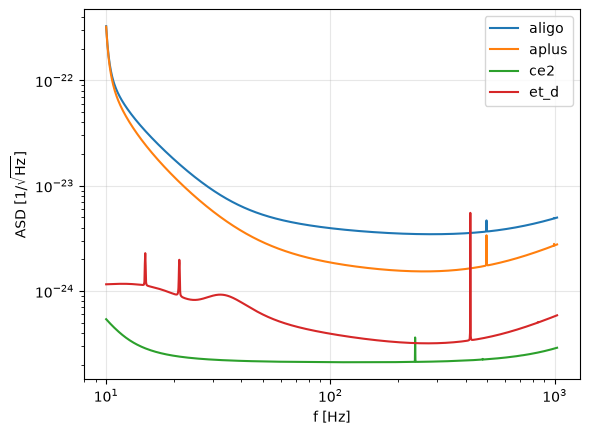

In [2]:
def read_mag(freq, fileName):
    f_tf, mag_tf = np.loadtxt(fileName, unpack=True)

    idx = np.where(f_tf>0)
    mag_tf = mag_tf[idx]
    f_tf = f_tf[idx]

    mag_func = interp.interp1d(np.log(f_tf), np.log(mag_tf), kind='linear', bounds_error=False, fill_value=np.inf)
    mag_out = np.exp(mag_func(np.log(freq)))
    return mag_out

# frequency grid: must match the PyCBC grid (multiples of delta_f), see below
df   = 1/16.
fmin = 10.
fmax = 1024.
freqs = np.arange(fmin, fmax + df/2, df)

psd = read_mag(freqs, 'curves/aligo.txt')**2   # ASD -> PSD

for name in ['aligo', 'aplus', 'ce2', 'et_d']:
    plt.loglog(freqs, read_mag(freqs, f'curves/{name}.txt'), label=name)
plt.xlabel('f [Hz]'); plt.ylabel(r'ASD [1/$\sqrt{\rm Hz}$]'); plt.legend(); plt.grid(alpha=.3)
plt.show()

## 3. Waveform model

We use `IMRPhenomD` from `pycbc.waveform.get_fd_waveform`, with mass inputs built from
$(\mathcal{M}_c, q)$ through `pycbc.conversions`. To keep things simple:

* The source is face-on ($\iota=0$) and we use $\tilde h_+$ with an antenna factor of $F_+ = 1$.
  The distance only sets the overall SNR.
* $t_c$ and $\phi_c$ enter as an **overall phase factor** that we apply by hand:
  $\tilde h(f) \to \tilde h(f)\, e^{2\pi i f t_c - i\phi_c}$.
  Their derivatives are known analytically:
  $\partial_{t_c}\tilde h = 2\pi i f\,\tilde h$ and $\partial_{\phi_c}\tilde h = -i\,\tilde h$.
  This makes a useful check on the numerical derivatives (Section 5).

The grid needs care. PyCBC returns a `FrequencySeries` that starts at $f=0$ with spacing `delta_f`.
To line it up with `freqs`, we slice from index `fmin/df` and set `f_final=fmax`. That way every
perturbed waveform lands on **exactly the same frequency samples**, which the finite differences require.

{'Mc': 28.095555795460438, 'q': 1.2413793103448276, 'tc': 0.0, 'phic': 0.0, 'Dl': 1000.0}


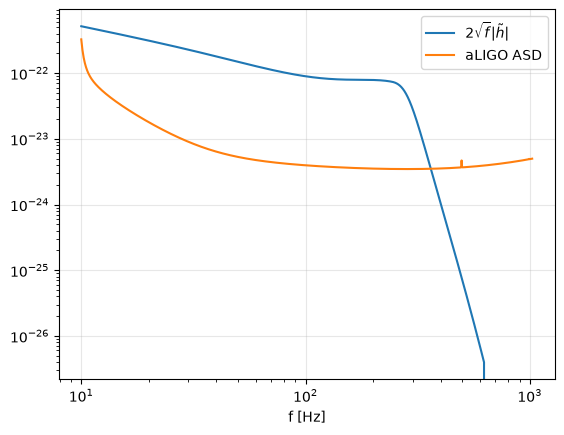

In [3]:
def waveform(freqs, par, approximant='IMRPhenomD'):
    m1 = pycbcConv.mass1_from_mchirp_q(par['Mc'], par['q'])   # q = m1/m2 >= 1
    m2 = pycbcConv.mass2_from_mchirp_q(par['Mc'], par['q'])

    hp, hc = pycbc.waveform.get_fd_waveform(approximant=approximant,
                                            mass1=m1, mass2=m2,
                                            distance=par['Dl'], inclination=0.,
                                            delta_f=df, f_lower=fmin, f_final=fmax)
    k0 = int(round(fmin/df))
    h = hp.data[k0:k0+len(freqs)]

    return h * np.exp(2j*np.pi*freqs*par['tc'] - 1j*par['phic'])

# injected (true) parameters, detector frame
m1, m2 = 36., 29.
par = {
    'Mc'   : pycbcConv.mchirp_from_mass1_mass2(m1, m2),
    'q'    : m1/m2,
    'tc'   : 0.,
    'phic' : 0.,
    'Dl'   : 1000.,   # Mpc (held fixed)
}
print(par)

h0 = waveform(freqs, par)
plt.loglog(freqs, 2*np.sqrt(freqs)*np.abs(h0), label=r'$2\sqrt{f}|\tilde h|$')
plt.loglog(freqs, np.sqrt(psd), label='aLIGO ASD')
plt.xlabel('f [Hz]'); plt.legend(); plt.grid(alpha=.3); plt.show()

## 4. Inner product and SNR

This is the inner product from Section 1, integrated with Simpson's rule over `freqs`.
The SNR is $\rho = \sqrt{(h|h)}$.

In [4]:
def innprod(hf1, hf2, psd, freqs):
    prod = 2. * simpson( (np.conj(hf1) * hf2 + hf1 * np.conj(hf2)) / psd , x=freqs)
    return np.real(prod)


snr = np.sqrt(innprod(h0, h0, psd, freqs))
print(f"SNR  = {snr:.3f}")

SNR  = 40.081


## 5. Numerical waveform derivatives

This is the core of the method. For each parameter $\theta^i$ we generate the waveform at shifted
parameter values $\theta^i \pm \delta$, **holding all other parameters fixed**, and take their central
difference at every frequency sample:
$$\partial_i \tilde h(f) \approx \frac{\tilde h(f;\theta^i+\delta) - \tilde h(f;\theta^i-\delta)}{2\delta} + \mathcal O(\delta^2).$$

Choosing $\delta$ is a tradeoff. If it is too large, the $\mathcal O(\delta^2)$ truncation error biases the
derivative. If it is too small, roundoff takes over, because $h_{+} - h_{-}$ is the difference of two
nearly equal numbers. A good check is to vary $\delta$ by a few orders of magnitude and confirm the
final errors don't change.

Two practical details:

* **Per-parameter step sizes `dpar`.** Parameters have very different scales, so each gets its own step.
  We use a relative step for $\mathcal M_c$ (`Mc*1e-6`) and absolute steps for the others.
* **`log_flag`.** If set, the derivative is multiplied by $\theta^i$, so it becomes
  $\partial h/\partial\ln\theta^i = \theta^i\,\partial h/\partial\theta^i$. The Fisher error on that
  parameter is then the *fractional* error $\sigma_{\theta}/\theta$. We use this for $\mathcal M_c$.
  It is useful for dimensionful quantities like masses and distance: the error comes out directly as a
  fraction, and the Fisher matrix entries have more similar sizes, which helps when inverting it.

The cell below also checks the numerical $t_c$ and $\phi_c$ derivatives against the analytic ones.

In [5]:
def deriv_wf(func_waveform, freqs, idx, par, dpar):
    # central difference: [h(x+dx) - h(x-dx)] / (2 dx), all other parameters held fixed
    dx = dpar[idx]
    par_u = par.copy(); par_u[idx] += dx
    par_d = par.copy(); par_d[idx] -= dx
    return (func_waveform(freqs, par_u) - func_waveform(freqs, par_d)) / (2*dx)

dpar = {
    'Mc'   : par['Mc']*1e-6,
    'q'    : 1e-6,
    'tc'   : 1e-6,
    'phic' : 1e-5,
}

# check the numerical derivatives against the analytic ones for tc and phic
relerr = lambda a, b: np.sqrt(innprod(a-b, a-b, psd, freqs)/innprod(b, b, psd, freqs))
print(f"tc   : relative error = {relerr(deriv_wf(waveform, freqs, 'tc',   par, dpar), 2j*np.pi*freqs*h0):.1e}")
print(f"phic : relative error = {relerr(deriv_wf(waveform, freqs, 'phic', par, dpar), -1j*h0):.1e}")

tc   : relative error = 3.0e-07
phic : relative error = 1.7e-11


## 6. Fisher matrix and errors

`fish` computes every derivative, then fills $\Gamma_{ij} = (\partial_i h|\partial_j h)$. The matrix is real
and symmetric, so we compute the upper triangle and mirror it. `idx_par` maps each parameter name to its
row in the matrix. Inverting gives the covariance, and its diagonal gives the $1\sigma$ errors.

In [6]:
def fish(freqs, func_waveform, par, dpar, idx_par, psd, log_flag):
    n_dof = len(idx_par)
    dh = np.zeros([n_dof, len(freqs)], dtype=np.complex128)

    for idx in idx_par:
        dh[idx_par[idx], :] = deriv_wf(func_waveform, freqs, idx, par, dpar)
        if log_flag[idx]:
            dh[idx_par[idx], :] *= par[idx]

    gamma = np.zeros([n_dof, n_dof])
    for i in range(n_dof):
        for j in range(i, n_dof):
            gamma[i, j] = innprod(dh[i, :], dh[j, :], psd, freqs)
    for i in range(n_dof):
        for j in range(i):
            gamma[i, j] = gamma[j, i]
    return gamma

idx_par  = {'Mc': 0, 'q': 1, 'tc': 2, 'phic': 3}
log_flag = {'Mc': True, 'q': False, 'tc': False, 'phic': False}

F   = fish(freqs, waveform, par, dpar, idx_par, psd, log_flag)
cov = np.linalg.inv(F)
sig = np.sqrt(np.diag(cov))

print(f"SNR = {snr:.1f}\n")
print(f"sigma(Mc)/Mc = {sig[0]:.2e}   (sigma_Mc = {sig[0]*par['Mc']:.3e} Msun)")
print(f"sigma(q)     = {sig[1]:.3f}")
print(f"sigma(tc)    = {sig[2]*1e3:.3f} ms")
print(f"sigma(phic)  = {sig[3]:.3f} rad")

# sanity checks on the matrix inversion
print("\nmax |F.C - I| =", f"{np.max(np.abs(F@cov - np.eye(len(F)))):.1e}")
print("condition number of F =", f"{np.linalg.cond(F):.1e}")

corr = cov/np.outer(sig, sig)
print("\ncorrelation matrix (lnMc, q, tc, phic):")
print(np.array2string(corr, precision=3, suppress_small=True))

SNR = 40.1

sigma(Mc)/Mc = 2.82e-03   (sigma_Mc = 7.932e-02 Msun)
sigma(q)     = 0.170
sigma(tc)    = 0.170 ms
sigma(phic)  = 0.349 rad

max |F.C - I| = 3.0e-11
condition number of F = 1.2e+08

correlation matrix (lnMc, q, tc, phic):
[[ 1.    -0.956 -0.805 -0.907]
 [-0.956  1.     0.911  0.748]
 [-0.805  0.911  1.     0.565]
 [-0.907  0.748  0.565  1.   ]]


**Things to notice**
* $\mathcal M_c$ is measured to a fraction of a percent. The mass ratio is measured far worse: it first
  shows up at higher post-Newtonian order and is strongly correlated with $\mathcal M_c$.
* $t_c$ and $\phi_c$ are strongly correlated with the intrinsic parameters. Fixing them (dropping those
  rows and columns) would make the $\mathcal M_c$ and $q$ errors look far too optimistic.
* Fisher errors scale as $1/\rho$. Doubling $D_L$ doubles every $\sigma$ (checked below).
* Check the condition number. With ~$10^{10}$ or more, the matrix inversion becomes unreliable, so it is
  worth checking that $F\cdot\Sigma = I$.

In [7]:
par2 = dict(par, Dl=2*par['Dl'])
sig2 = np.sqrt(np.diag(np.linalg.inv(fish(freqs, waveform, par2, dpar, idx_par, psd, log_flag))))
print("sigma(2 Dl) / sigma(Dl) =", np.round(sig2/sig, 4))

sigma(2 Dl) / sigma(Dl) = [2. 2. 2. 2.]


## 7. $1\sigma$ ellipse in $(\mathcal M_c, q)$

The marginalized 2D covariance of a pair of parameters is just the matching $2\times2$ block of
$\Sigma$. We plot it together with a (fake) Gaussian posterior sample.

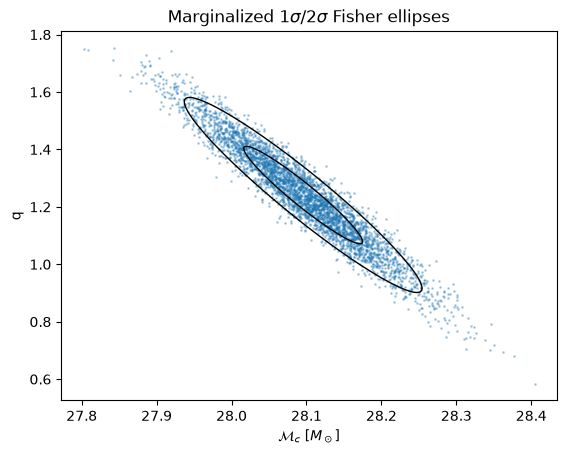

In [8]:
C2 = cov[:2, :2].copy()
C2[0, :] *= par['Mc']; C2[:, 0] *= par['Mc']   # ln Mc -> Mc
mean = np.array([par['Mc'], par['q']])

samples = np.random.default_rng(0).multivariate_normal(mean, C2, 4000)
w, v = np.linalg.eigh(C2)
t = np.linspace(0, 2*np.pi, 200)
for n in [1, 2]:
    ell = mean[:, None] + n * v @ (np.sqrt(w)[:, None]*np.array([np.cos(t), np.sin(t)]))
    plt.plot(*ell, 'k', lw=1)
plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=.3)
plt.xlabel(r'$\mathcal{M}_c\ [M_\odot]$'); plt.ylabel('q')
plt.title(r'Marginalized 1$\sigma$/2$\sigma$ Fisher ellipses')
plt.show()

## 8. Swapping detectors

The noise curve is just the input `psd`, so changing the detector is a single line.

In [9]:
for name in ['aligo', 'aplus', 'voyager', 'ce2', 'et_d']:
    psd_d = read_mag(freqs, f'curves/{name}.txt')**2
    s = np.sqrt(np.diag(np.linalg.inv(fish(freqs, waveform, par, dpar, idx_par, psd_d, log_flag))))
    rho = np.sqrt(innprod(h0, h0, psd_d, freqs))
    print(f"{name:8s} SNR={rho:7.1f}  dMc/Mc={s[0]:.1e}  dq={s[1]:.1e}  dtc={s[2]*1e3:.2e} ms  dphic={s[3]:.2e}")

aligo    SNR=   40.1  dMc/Mc=2.8e-03  dq=1.7e-01  dtc=1.70e-01 ms  dphic=3.49e-01


aplus    SNR=   76.8  dMc/Mc=1.7e-03  dq=9.5e-02  dtc=8.75e-02 ms  dphic=2.42e-01
voyager  SNR=  175.8  dMc/Mc=6.7e-04  dq=4.0e-02  dtc=4.04e-02 ms  dphic=8.25e-02


ce2      SNR= 1542.7  dMc/Mc=4.1e-05  dq=3.4e-03  dtc=5.75e-03 ms  dphic=2.83e-03


et_d     SNR=  503.4  dMc/Mc=1.1e-04  dq=9.2e-03  dtc=1.25e-02 ms  dphic=7.32e-03


Here `fmin = 10 Hz` is fixed for every detector. For CE or ET you would lower `fmin` to about 5 Hz,
using a smaller `df` so the longer signal is resolved. That improves the $\mathcal M_c$ error much more
than the SNR alone suggests.

## Next steps

* Add $D_L$, $\iota$, sky location and polarization, with detector projections via
  `pycbc.detector.Detector.antenna_pattern`.
* Sum Fisher matrices over a detector network: $\Gamma_{\rm net} = \sum_d \Gamma_d$.
* Add priors as a diagonal Fisher term, $\Gamma_{ii} \mathrel{+}= 1/\sigma_{\rm prior}^2$, to tame poorly
  constrained directions (e.g. $\phi_c$ within $[0, 2\pi]$).